# <center> Antrenarea YOLO pe 3 dataset-uri imbinate <center>

## <center>**1: Combinare dataset-uri YOLO pentru antrenare unificata**<center>
In aceasta sectiune construim un singur dataset YOLO pornind de la trei surse diferite:  
- **Aircraft Detection** (83 clase)  
- **Military Object Dataset** (12 clase)  
- **Mar20** (20 clase)

### **Procesarea si combinarea dataset-urilor**

Functiile `copy_and_rename` si `process_dataset` au rolul de a:  
- copia imaginile si fisierele label in noile foldere,  
- redenumi fisierele pentru a evita coliziuni,  
- ajusta indexul claselor pentru a pastra consistenta.  

In final obtinem un dataset unificat cu **115 clase** si un fisier `data.yaml` care contine:  
- path-urile pentru train/val/test,  
- numarul de clase,  
- lista completa a etichetelor (avioane, vehicule, soldati etc.).  


In [ ]:
import os
import shutil
from typing import List


def copy_and_rename(src_img_dir : str, src_lbl_dir : str, dst_img_dir : str, dst_lbl_dir : str, start_index : int, class_offset = 0) -> int:
    index = start_index
    for img_file in sorted(os.listdir(src_img_dir)):
        img_file : str

        # Verificam sa fie o imagine valida
        if not img_file.endswith(".jpg"):
            continue

        # Asociere imagine-label
        lbl_file : str = img_file.replace(".jpg", ".txt")

        img_src = os.path.join(src_img_dir, img_file)
        lbl_src = os.path.join(src_lbl_dir, lbl_file)

        new_img_name = f"{index}.jpg"
        new_lbl_name = f"{index}.txt"
        img_dst = os.path.join(dst_img_dir, new_img_name)
        lbl_dst = os.path.join(dst_lbl_dir, new_lbl_name)

        # Copiem imaginile
        shutil.copyfile(img_src, img_dst)

        # Si procesam label pt offset si rescriere clase
        if os.path.exists(lbl_src):
            with open(lbl_src, "r") as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, x, y, w, h = parts
                    cls = str(int(cls) + class_offset)
                    new_lines.append(" ".join([cls, x, y, w, h]))

                with open(lbl_dst, "w") as f:
                    f.write("\n".join(new_lines))

        index += 1

    return index # pentru a putea fi folosit mai departe


def process_dataset(directories : List[str], working_path : str, output_working_path : str, ind_counter : int, cls_offset : int = 0) -> int:
    for split in directories:
        src_img_dir = os.path.join(working_path, split, "images")
        src_lbl_dir = os.path.join(working_path, split, "labels")

        dst_img_dir = os.path.join(output_working_path, split if split != "valid" else "val", "images")
        dst_lbl_dir = os.path.join(output_working_path, split if split != "valid" else "val", "labels")

        ind_counter = copy_and_rename(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, ind_counter,
                                        class_offset=cls_offset)

    return ind_counter


def main() -> None:
    aircraft_path = "/kaggle/input/aircraft-detection/"
    military_path = "/kaggle/input/military-detection/military_object_dataset/"
    mar20_path = "/kaggle/input/mar20-yolo/mar20_yolo"

    # Vom avea un dataset cu folderele train, test si val
    output_path = "/kaggle/working/military-dataset"
    os.makedirs(output_path, exist_ok=True)

    # Structura yolo
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_path, split, "images"), exist_ok=True)
        os.makedirs(os.path.join(output_path, split, "labels"), exist_ok=True)


    index_counter = 1

    # Primul dataset are folderele numite train, test si valid si are 83 de clase
    index_counter = process_dataset(["train", "valid", "test"], aircraft_path, output_path, index_counter, cls_offset=0)
    # Al doilea dataset are folderele numite train, test si val si are 12  clase
    index_counter = process_dataset(["train", "val", "test"], military_path, output_path,  index_counter,cls_offset=83)
    # Al treilea dataset are folderele numite train, test si val si are 20 de clase
    process_dataset(["train", "val", "test"], mar20_path, output_path,  index_counter,cls_offset=95)

    # Config
    yaml_content = """train: train/images
val: val/images
test: test/images
nc: 115
names: ['Mi28', 'UH60', 'F16', 'H6', 'F18', 'F22', 'F35', 'JAS39', 'B52', 'JH7', 'KF21', 'US2', 'Be200', 'AG600', 'EF2000', 'C2', 'P3', 'CL415', 'E2', 'Rafale', 'Mig31', 'Su25', 'XB70', 'YF23', 'Su57', 'F15', 'KC135', 'An72', 'An22', 'B2', 'An124', 'Tu160', 'C5', 'Il76', 'J20', 'B1', 'C130', 'A10', 'V22', 'C390', 'F117', 'WZ7', 'E7', 'CH47', 'AH64', 'AV8B', 'Mi24', 'U2', 'KJ600', 'RQ4', 'Tu22M', 'SR71', 'J10', 'Mirage2000', 'Tu95', 'A400M', 'MQ9', 'F14', 'Su34', 'F4', 'Mi8', 'Mig29', 'Z10', 'JF17', 'TB001', 'KAAN', 'Ka52', 'C17', 'EMB314', 'An225', 'Y20', 'Su24', 'TB2', 'Ka27', 'Tornado', 'Vulcan', 'Z19', 'V280', 'Mi26', 'J36', 'J35', 'B21', 'WZ9',
'camouflage_soldier', 'weapon', 'military_tank', 'military_truck', 'military_vehicle', 'civilian', 'soldier', 'civilian_vehicle', 'military_artillery', 'trench', 'military_aircraft', 'military_warship',
'A1','A10','A11','A12','A13','A14','A15','A16','A17','A18','A19','A2','A20','A3','A4','A5','A6','A7','A8','A9']
    """

    with open(os.path.join(output_path, "data.yaml"), "w") as f:
        f.write(yaml_content)

    print("Dataset-ul a fost creat si salvat in ", output_path)


if __name__ == "__main__":
    main()


## <center>**2: Finetunare YOLO pe dataset combinat**<center>
Dupa creare, incarcam modelul preantrenat. Ca parametrii:  
- **epochs = 50**  
- **batch size = 16**  
- **imgsz = 256**  
- **optimizer = AdamW**  
- **workers = 12**  
- **patience = 10** (early stopping)  
- **half precision = True** (accelerare pe GPU)
 
Validarea este rulata pe split-ul `val`, pentru a evalua metrice precum mAP, precizie si recall.


In [6]:
from ultralytics import YOLO
from pathlib import Path

WORK = Path("/kaggle/input/military-dataset")
DATA_YAML = WORK / "data.yaml"
RUN_NAME = "yolov8_finetune_military_dataset_opt"

# Modelul preantrenat YOLOv8 medium
model = YOLO("yolov8m.pt")

model.train(
    data = str(DATA_YAML),
    epochs = 80,           
    imgsz = 320,          
    batch = 16,             
    device = 0,
    workers = 12,
    patience = 20,        
    pretrained = True,
    half = True,
    optimizer = "AdamW",     
    lr0 = 0.001,             
    weight_decay = 0.01,     
    name = RUN_NAME,
    save = True,
    save_txt = False,
    save_conf = False,
    cache = True,
    copy_paste = 0.3,       
    hsv_h = 0.015,            
    hsv_s = 0.7,
    hsv_v = 0.4,
    flipud = 0.5,
    fliplr = 0.5,
)


Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/military-dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=True, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_finetune_military_dataset_opt, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

KeyboardInterrupt: 

## <center>**3: Reluarea antrenarii**<center>
Daca se doreste continuarea de la un checkpoint anterior (`best.pt`), YOLO permite re-incarcarea si antrenarea suplimentara pentru cateva epoci. Astfel se poate imbunatati performanta fara a relua intregul proces.

In [ ]:
from ultralytics import YOLO
from pathlib import Path

WORK = Path("/kaggle/input/military-dataset")
DATA_YAML = WORK / "data.yaml"

model = YOLO("/kaggle/working/runs/detect/yolov8_finetune_military_dataset/weights/last.pt")

model.train(
    data = str(DATA_YAML),
    resume = True 
)

Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/military-dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=True, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/detect/yolov8_finetune_military_dataset/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_finetune_military_dataset, nbs=64, nms=False, 

## <center>**4: Inferenta si predictii**<center>
Dupa antrenare:  
- se incarca modelul optim (`best.pt`),  
- se selecteaza un set de imagini random din `test/images`,  
- se ruleaza predictia si se afiseaza bounding box-urile.  


0: 256x256 (no detections), 3.4ms
1: 256x256 1 military_tank, 3.4ms
2: 256x256 5 A1s, 1 A19, 3.4ms
3: 256x256 (no detections), 3.4ms
4: 256x256 6 military_tanks, 3.4ms
Speed: 0.6ms preprocess, 3.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)


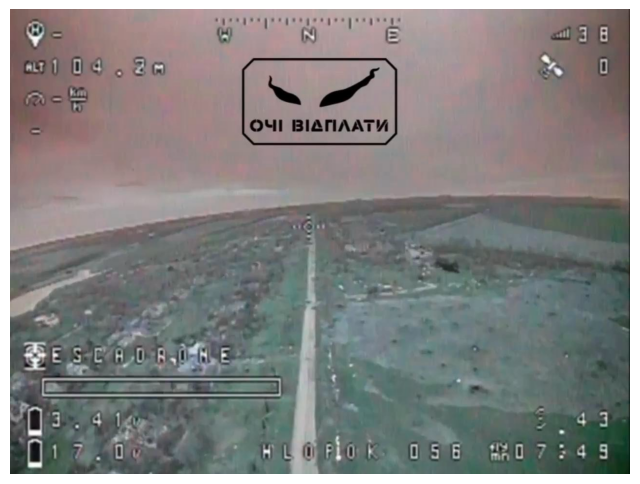

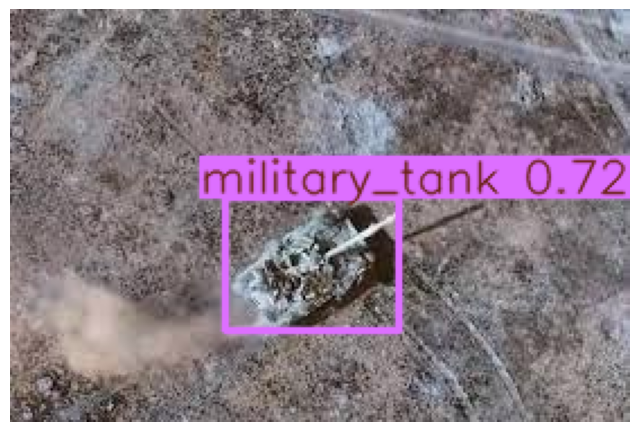

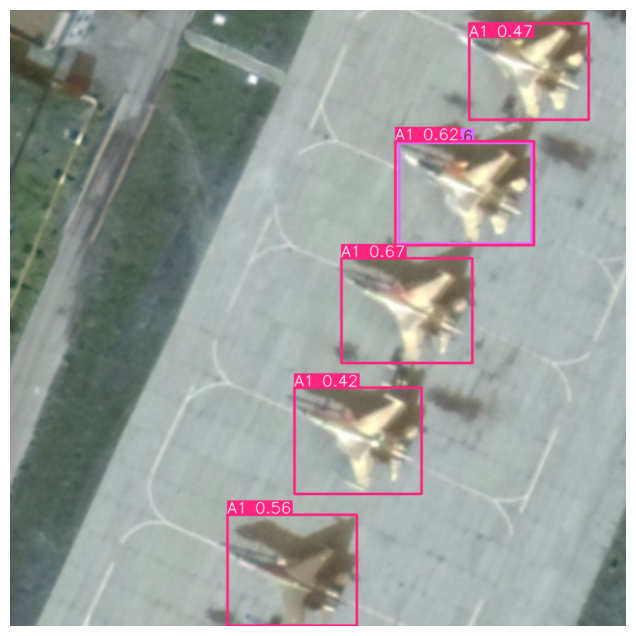

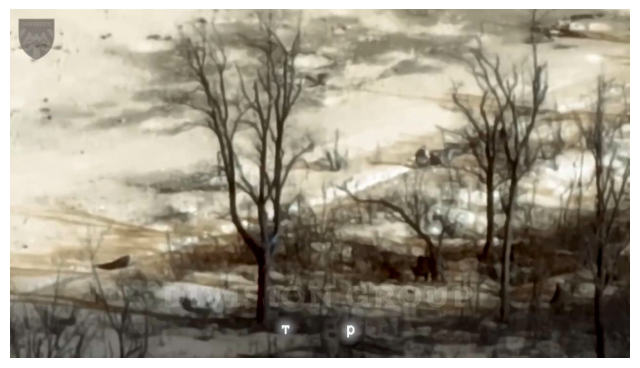

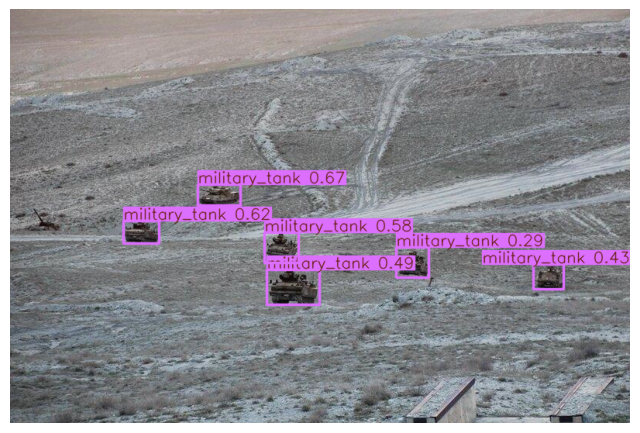

In [3]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

WORK = Path("/kaggle/input/military-dataset/")
model_path = Path("/kaggle/working/runs/detect/yolov8_finetune_military_dataset/weights/best.pt")

model = YOLO(str(model_path))

test_images = list((WORK / "test/images").glob("*.jpg"))
sample_imgs = random.sample(test_images, 5)  # 5 imagini random

preds = model.predict(
    source = [str(img) for img in sample_imgs],
    imgsz = 256,
    device = 0,
    save = False,
    conf = 0.25
)

for pred in preds:
    plt.figure(figsize=(8, 8))
    plt.imshow(pred.plot())
    plt.axis("off")
    plt.show()


## <center>**5: Export si download**<center>
La final, predictiile si modelul pot fi salvate intr-un fisier zip pentru a fi descarcate si utilizate ulterior.

In [ ]:
import shutil
from pathlib import Path

folder_to_zip = Path("/kaggle/working/predictions/yolo_preds")
zip_output = Path("/kaggle/working/predictions/yolo_preds.zip")

shutil.make_archive(base_name=str(zip_output.with_suffix('')), format='zip', root_dir=folder_to_zip)

print(f"Folderul a fost comprimat la: {zip_output}")
init -p  /kaggle/working/military-dataset